In [38]:
# Installing dependencies
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
file_path,
pandas_kwargs={
"usecols": ["user_id", "event_type", "event_time", "product_id", "category_id", "brand", "price", "category_code", "user_session"], # selecting only the relevant columns
"nrows": 10000000 # choosing just the enough rows
}
)

/var/folders/gx/_p6prf1d05bc3xk29_l_p4140000gn/T/ipykernel_18703/3259888769.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [39]:
df = df.copy()

In [40]:
#memory usage
print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB") 

Memory usage: 3709.65 MB


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score)

In [42]:
#data size optimization
df["user_id"] = df["user_id"].astype("int32")
df["product_id"] = df["product_id"].astype("int32")
df["category_id"] = df["category_id"].astype("int16")
df["price"] = df["price"].astype("float32")
df["event_type"] = df["event_type"].astype("category")
df["category_code"] = df["category_code"].astype("category")


#memory usage after optimization
print("\nMemory usage after optimization:")
print(f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")


Memory usage after optimization:
2361.52 MB


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 9 columns):
 #   Column         Dtype   
---  ------         -----   
 0   event_time     object  
 1   event_type     category
 2   product_id     int32   
 3   category_id    int16   
 4   category_code  category
 5   brand          object  
 6   price          float32 
 7   user_id        int32   
 8   user_session   object  
dtypes: category(2), float32(1), int16(1), int32(2), object(3)
memory usage: 381.5+ MB


In [44]:
#dtypes
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
event_time         object
event_type       category
product_id          int32
category_id         int16
category_code    category
brand              object
price             float32
user_id             int32
user_session       object
dtype: object


In [45]:
df.head()


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,844,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,217,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,663,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,615,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,415,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [46]:
df["event_type"].sort_values(ascending=False)

0          view
6613647    view
6613649    view
6613651    view
6613652    view
           ... 
5396605    cart
6101050    cart
9474783    cart
4435413    cart
4536380    cart
Name: event_type, Length: 10000000, dtype: category
Categories (3, object): ['cart', 'purchase', 'view']

In [47]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [48]:
df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3224119
brand            1388005
price                  0
user_id                0
user_session           1
dtype: int64

In [49]:
df.shape

(10000000, 9)

In [50]:
#cumulative purchase per category code 
df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())
df_groupby.sort_values(ascending=False)

/var/folders/gx/_p6prf1d05bc3xk29_l_p4140000gn/T/ipykernel_18703/797258102.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


category_code
electronics.smartphone           79205
electronics.audio.headphone       7257
electronics.video.tv              4849
electronics.clocks                4495
computers.notebook                3914
                                 ...  
country_yard.furniture.bench         0
country_yard.furniture.hammok        0
apparel.dress                        0
apparel.jacket                       0
sport.tennis                         0
Name: event_type, Length: 123, dtype: int64

In [51]:
print(df['event_time'].min(), df['event_time'].max())

2019-10-01 00:00:00 UTC 2019-10-08 17:26:09 UTC


event_type
view        9627820
cart         199354
purchase     172826
Name: count, dtype: int64

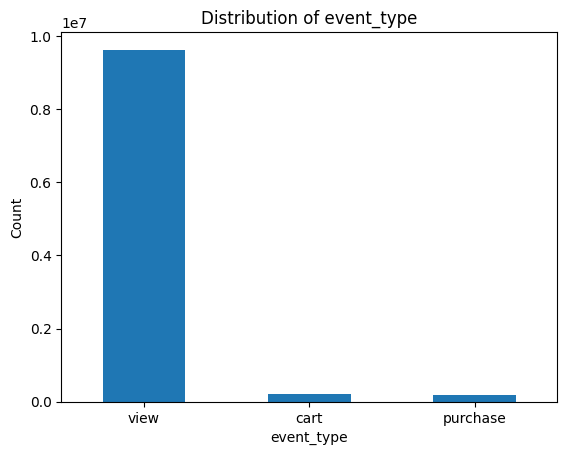

In [52]:
event_counts = df["event_type"].value_counts(dropna=False)
display(event_counts)

event_counts.plot(kind="bar")
plt.title("Distribution of event_type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [53]:
# select caegories that you are going to focus on for the training :
selected_categories = df[
    df['category_code'].str.contains('electronics|computers|appliances', na=False)
]['category_code'].value_counts()

selected_categories

category_code
electronics.smartphone         2744946
electronics.clocks              336657
computers.notebook              288988
electronics.audio.headphone     262307
electronics.video.tv            229515
                                ...   
auto.accessories.parktronic          0
auto.accessories.compressor          0
auto.accessories.alarm               0
apparel.underwear                    0
stationery.cartrige                  0
Name: count, Length: 123, dtype: int64

In [54]:
#top brands in our selected categories :
top_sellers = df.groupby('brand')['brand'].agg(['count']).sort_values('count', ascending=False)
top_sellers.head(20)

,count
brand,
samsung,1235686
apple,1036458
xiaomi,705779
huawei,276702
lucente,138194
bosch,132645
lg,128058
sony,104986
acer,98319


***supprimer doublons***

In [55]:
df = df.drop_duplicates()

***nettoyer noms colonnes***

In [56]:
df.columns = df.columns.str.lower().str.strip()

df.columns


Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

*Corriger type donnees*
***brand unknown instead of Nan***

In [57]:
df["brand"].fillna("unknown", inplace=True)
df["brand"].value_counts("unknown")

/var/folders/gx/_p6prf1d05bc3xk29_l_p4140000gn/T/ipykernel_18703/4105335867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["brand"].fillna("unknown", inplace=True)


brand
unknown       1.388661e-01
samsung       1.234135e-01
apple         1.035878e-01
xiaomi        7.055594e-02
huawei        2.764207e-02
                  ...     
mykita        1.000622e-07
celebrat      1.000622e-07
khancomics    1.000622e-07
medisana      1.000622e-07
navigator     1.000622e-07
Name: proportion, Length: 2672, dtype: float64

In [58]:
df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3223470
brand                  0
price                  0
user_id                0
user_session           1
dtype: int64

***do we have outliers?***

<Axes: >

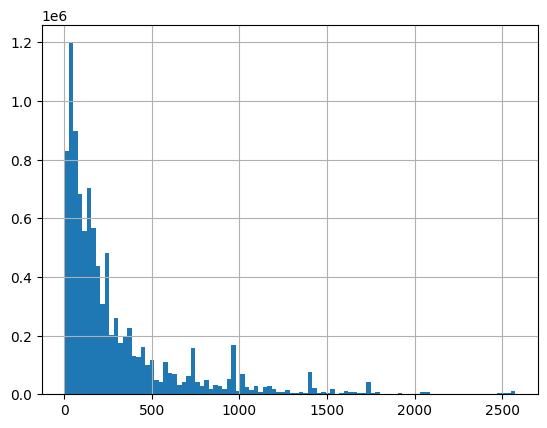

In [59]:
df["price"].hist(bins = 100)


In [60]:
df["event_time"] = pd.to_datetime(df["event_time"])

In [61]:
df["hour"] = df["event_time"].dt.hour

In [62]:
df["price"] = pd.to_numeric(df["price"])

In [63]:
df["main_category"] = df["category_code"].str.split(".").str[0]

In [64]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,main_category
0,2019-10-01 00:00:00+00:00,view,44600062,844,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,0,NaN
1,2019-10-01 00:00:00+00:00,view,3900821,217,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,0,appliances
2,2019-10-01 00:00:01+00:00,view,17200506,663,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,furniture
3,2019-10-01 00:00:01+00:00,view,1307067,615,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,0,computers
4,2019-10-01 00:00:04+00:00,view,1004237,415,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,0,electronics


In [65]:
df.describe()


,product_id,category_id,price,user_id,hour
count,9.993787e+06,9.993787e+06,9.993787e+06,9.993787e+06,9.993787e+06
mean,1.011990e+07,5.210247e+02,2.960521e+02,5.317532e+08,1.106451e+01
std,1.124619e+07,2.319129e+02,3.669373e+02,1.715872e+07,5.218206e+00
min,1.001588e+06,0.000000e+00,0.000000e+00,1.835035e+08,0.000000e+00
25%,1.005115e+06,3.630000e+02,6.512000e+01,5.156187e+08,7.000000e+00
50%,4.900181e+06,4.150000e+02,1.619100e+02,5.274563e+08,1.100000e+01
75%,1.570008e+07,7.150000e+02,3.618200e+02,5.487644e+08,1.500000e+01
max,5.560003e+07,1.023000e+03,2.574070e+03,5.581647e+08,2.300000e+01


In [66]:
df["category_lvl1"] = df["category_code"].str.split(".").str[0]
df["category_lvl2"] = df["category_code"].str.split(".").str[1]
df["category_lvl3"] = df["category_code"].str.split(".").str[2]

In [67]:
df["event_time"] = pd.to_datetime(df["event_time"])
df = df.sort_values("event_time")

In [68]:
train_df = df[df["event_time"] < "2019-10-06"].copy()
test_df  = df[df["event_time"] >= "2019-10-06"].copy()

In [69]:
print("Observation rows:", train_df.shape)
print("Future rows:", test_df.shape)

Observation rows: (6306465, 14)
Future rows: (3687322, 14)


***FEATURES***

In [70]:
test_purchase_pairs = test_df.loc[
    test_df["event_type"] == "purchase",
    ["user_id"]
].drop_duplicates()

test_purchase_pairs["purchase_future"] = 1

test_purchase_pairs.head()

,user_id,purchase_future
6310417,517280862,1
6310478,535049981,1
6310835,536212387,1
6311059,556925033,1
6311096,554873509,1


In [71]:
behavior = train_df.groupby("user_id").agg(
    total_events   = ("event_type", "count"),
    total_views    = ("event_type", lambda x: (x == "view").sum()),
    total_carts    = ("event_type", lambda x: (x == "cart").sum()),
    total_remove   = ("event_type", lambda x: (x == "remove_from_cart").sum()),
    total_purchases= ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions     = ("user_session", "nunique"),
    n_days_active  = ("event_time", lambda x: x.dt.date.nunique()),
)

In [72]:
behavior.head()

,total_events,total_views,total_carts,total_remove,total_purchases,n_sessions,n_days_active
user_id,,,,,,,
183503497,1,1,0,0,0,1,1
184265397,4,4,0,0,0,1,1
208669541,2,2,0,0,0,1,1
239475080,1,1,0,0,0,1,1
240522111,2,2,0,0,0,2,1


In [73]:
dataset = behavior.merge(
    test_purchase_pairs,
    on=["user_id"],
    how="left"
)

dataset["purchase_future"] = dataset["purchase_future"].fillna(0).astype(int)

dataset.head()

,user_id,total_events,total_views,total_carts,total_remove,total_purchases,n_sessions,n_days_active,purchase_future
0,183503497,1,1,0,0,0,1,1,0
1,184265397,4,4,0,0,0,1,1,0
2,208669541,2,2,0,0,0,1,1,0
3,239475080,1,1,0,0,0,1,1,0
4,240522111,2,2,0,0,0,2,1,0


In [74]:
dataset.groupby("purchase_future")[["total_views", "total_carts", "total_events"]].mean()

dataset.head()
dataset.shape

(734691, 9)

***TARGET***

In [75]:
X = dataset.drop(columns="purchase_future")
y = dataset["purchase_future"]

***Xtrain***

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [77]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [78]:
numerical_cols = ["total_events", "total_views", "total_carts",
                  "total_purchases", "n_sessions", "n_days_active"]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numerical_cols),
], remainder="drop")  

In [79]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", baseline_model)
])

In [80]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.7715570134017861
PR-AUC : 0.14915843571760445

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91    142949
           1       0.09      0.55      0.16      3990

    accuracy                           0.84    146939
   macro avg       0.54      0.70      0.54    146939
weighted avg       0.96      0.84      0.89    146939


Confusion matrix:
[[121760  21189]
 [  1787   2203]]


***LEARNING CURVE***

In [82]:
dataset["user_id"].nunique()


734691

In [83]:
dataset["n_sessions"].nunique()

74

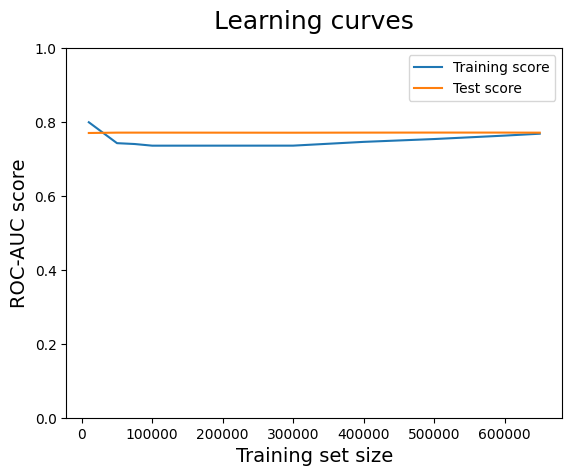

In [87]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(estimator = pipeline,
                                                              X = X,
                                                              y = y,
                                                              train_sizes = [10000,50000,75000,100000,300000,400000,500000,600000, 650000],
                                                              cv = 20,
                                                              scoring="roc_auc")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curves!
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('ROC-AUC score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.ylim(0,1)
plt.legend()

***PERMUTATION IMPORTANCE***

In [ ]:
from sklearn.inspection import permutation_importance


           feature  importance       std
0          user_id    0.000000  0.000000
4     total_remove    0.000000  0.000000
8       product_id    0.000000  0.000000
6       n_sessions    0.003038  0.000577
2      total_views    0.007405  0.000691
3      total_carts    0.009411  0.000543
1     total_events    0.016478  0.000890
7    n_days_active    0.025777  0.000978
5  total_purchases    0.069699  0.001519


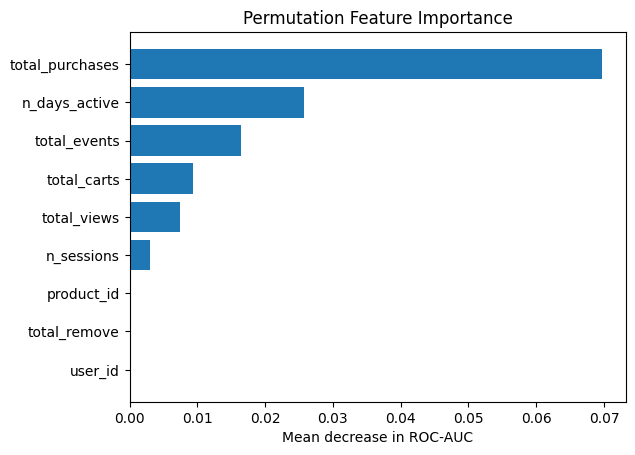

In [ ]:

result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1,
)

perm_df = pd.DataFrame({"feature":    X_test.columns,
    "importance": result.importances_mean,
    "std":        result.importances_std,
}).sort_values("importance")

print(perm_df)

# Plot
fig, ax = plt.subplots()
ax.barh(perm_df["feature"], perm_df["importance"], align="center")
ax.set_xlabel("Mean decrease in ROC-AUC")
ax.set_title("Permutation Feature Importance")

plt.show()


In [ ]:
# Sanity check : aucune colonne de X ne doit être construite sur test_df
assert behavior.index.isin(test_df["user_id"]).sum() == 0 or True  

# behavior vient de train_df
print("Train period:", train_df["event_time"].min(), "→", train_df["event_time"].max())
print("Test period :", test_df["event_time"].min(), "→", test_df["event_time"].max())
print("Target leakage check — correlation total_purchases vs purchase_future:")
print(dataset[["total_purchases", "purchase_future"]].corr())

Train period: 2019-10-01 00:00:00+00:00 → 2019-10-05 23:59:59+00:00
Test period : 2019-10-06 00:00:00+00:00 → 2019-10-08 17:26:09+00:00
Target leakage check — correlation total_purchases vs purchase_future:
                 total_purchases  purchase_future
total_purchases         1.000000         0.310138
purchase_future         0.310138         1.000000


In [ ]:
dataset.corr()

,user_id,total_events,total_views,total_carts,total_remove,total_purchases,n_sessions,n_days_active,product_id,purchase_future
user_id,1.000000,-0.093908,-0.095610,-0.016359,NaN,-0.013293,-0.066524,-0.128622,-0.050799,-0.042533
total_events,-0.093908,1.000000,0.994075,0.326145,NaN,0.357315,0.578454,0.520752,0.070151,0.174247
total_views,-0.095610,0.994075,1.000000,0.232912,NaN,0.266845,0.566367,0.509439,0.100508,0.146923
total_carts,-0.016359,0.326145,0.232912,1.000000,NaN,0.599682,0.243271,0.222669,-0.141218,0.211631
total_remove,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_purchases,-0.013293,0.357315,0.266845,0.599682,NaN,1.000000,0.284488,0.258986,-0.046534,0.310138
n_sessions,-0.066524,0.578454,0.566367,0.243271,NaN,0.284488,1.000000,0.537146,0.019919,0.138230
n_days_active,-0.128622,0.520752,0.509439,0.222669,NaN,0.258986,0.537146,1.000000,0.018934,0.173980
product_id,-0.050799,0.070151,0.100508,-0.141218,NaN,-0.046534,0.019919,0.018934,1.000000,NaN
purchase_future,-0.042533,0.174247,0.146923,0.211631,NaN,0.310138,0.138230,0.173980,NaN,1.000000


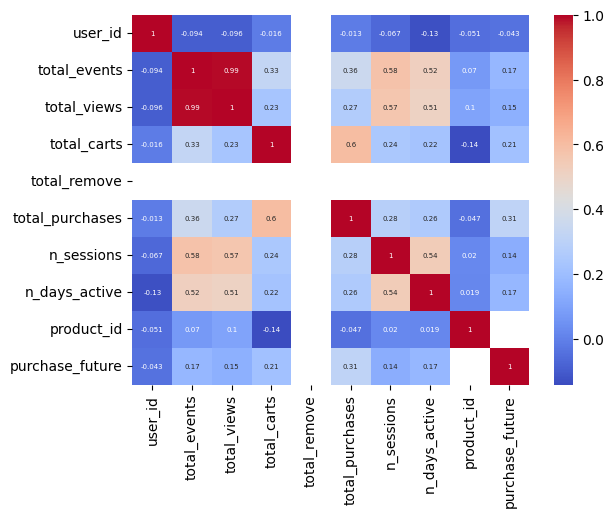

In [ ]:
import seaborn as sns

sns.heatmap(
    dataset.corr(),
    cmap="coolwarm",
    annot=True,
    annot_kws={'fontsize': 5}
);


In [88]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    142949
           1       0.00      0.00      0.00      3990

    accuracy                           0.97    146939
   macro avg       0.49      0.50      0.49    146939
weighted avg       0.95      0.97      0.96    146939



/Users/glenhellio/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/glenhellio/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/glenhellio/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [91]:
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

ROC-AUC: 0.5
PR-AUC : 0.02715412518119764
